1. Préparation des données

1.1. Types des données

Importation des librairies

In [ ]:
import pandas as pd
import json
import matplotlib.pyplot as plt
import matplotlib.pyplot as plt
import umap
import seaborn as sns
from mlxtend.frequent_patterns import fpgrowth, apriori, association_rules
from mlxtend.preprocessing import TransactionEncoder

c:\Users\lucna\.conda\envs\IFT599_TP1\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Lecture des données

In [53]:
df1 = pd.read_csv("cards_data.csv")
df2 = pd.read_csv("users_data.csv")
# Quantité importante de données de transactions, les fusions suivantes demandent trop de ressources, d'où la nécessité d'échantillonner
df3 = pd.read_csv("transactions_data.csv").tail(10000)  # pas ".sample(frac=0.10, random_state=42)" pour mieux refléter les séquences réelles
with open('train_fraud_labels.json', 'r') as df4:
    data1 = json.load(df4)
with open('mcc_codes.json', 'r') as df5:
    data2 = json.load(df5)

print()  # afin d'éviter de faire crash le notebook par l'affichage

Fusion de toutes les données

In [3]:
df2.rename(columns={"id": "client_id"}, inplace=True)

df_fusion = pd.merge(df1,df2, on="client_id", how="inner")
df_fusion.rename(columns={"id": "card_id"}, inplace=True)

df_fusion1 = pd.merge(df_fusion,df3, on=["client_id","card_id"], how="inner")
# Transformer le dictionnaire mcc en DataFrame
df_mcc = pd.DataFrame(list(data2.items()), columns=["mcc", "description"])
# Assurer que les types sont compatibles (int vs str)
df_fusion1["mcc"] = df_fusion1["mcc"].astype(int)
df_mcc["mcc"] = df_mcc["mcc"].astype(int)
# Fusionner sur la colonne 'code_mcc'
df_fusion2 = pd.merge(df_fusion1, df_mcc, on="mcc", how="left")

# Transformer le dictionnaire train_fraud_labels en DataFrame
# S'assurer que les types sont compatibles
df_fraud = pd.DataFrame(list(data1["target"].items()), columns=["id", "Statut"])
df_fusion2["id"] = df_fusion1["id"].astype(str)
df_fraud["id"] = df_fraud["id"].astype(str)
# Fusionner sur la colonne 'id'
df_fusion3 = pd.merge(df_fusion2, df_fraud, on="id", how="left")
df_fusion3.columns

Index(['card_id', 'client_id', 'card_brand', 'card_type', 'card_number',
       'expires', 'cvv', 'has_chip', 'num_cards_issued', 'credit_limit',
       'acct_open_date', 'year_pin_last_changed', 'card_on_dark_web',
       'current_age', 'retirement_age', 'birth_year', 'birth_month', 'gender',
       'address', 'latitude', 'longitude', 'per_capita_income',
       'yearly_income', 'total_debt', 'credit_score', 'num_credit_cards', 'id',
       'date', 'amount', 'use_chip', 'merchant_id', 'merchant_city',
       'merchant_state', 'zip', 'mcc', 'errors', 'description', 'Statut'],
      dtype='object')

Exploration des 25000 premières lignes de donéées

In [4]:
# Désactiver la troncature des lignes
df_fusion3.iloc[1:25000]


,card_id,client_id,card_brand,card_type,card_number,expires,cvv,has_chip,num_cards_issued,credit_limit,...,amount,use_chip,merchant_id,merchant_city,merchant_state,zip,mcc,errors,description,Statut
1,2731,825,Visa,Debit,4956965974959986,12/2020,393,YES,2,$21968,...,$160.00,Chip Transaction,27092,Mira Loma,CA,91752.0,4829,NaN,Money Transfer,NaN
2,3701,825,Visa,Debit,4582313478255491,02/2024,719,YES,2,$46414,...,$64.70,Chip Transaction,71667,La Verne,CA,91750.0,7538,NaN,Automotive Service Shops,NaN
3,42,825,Visa,Credit,4879494103069057,08/2024,693,NO,1,$12400,...,$128.79,Swipe Transaction,81833,La Verne,CA,91750.0,5912,NaN,Drug Stores and Pharmacies,No
4,3687,1746,Mastercard,Debit,5627220683410948,06/2022,48,YES,2,$9022,...,$104.16,Chip Transaction,13646,Corona,NY,11368.0,7538,NaN,Automotive Service Shops,NaN
5,3687,1746,Mastercard,Debit,5627220683410948,06/2022,48,YES,2,$9022,...,$97.23,Chip Transaction,31329,Little Neck,NY,11363.0,7538,NaN,Automotive Service Shops,No
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,4046,185,Mastercard,Debit,5916545236079509,07/2024,314,YES,1,$16415,...,$2.84,Chip Transaction,17493,Elizabeth,NJ,7202.0,5812,NaN,Eating Places and Restaurants,NaN
9996,5361,185,Amex,Credit,300609782832003,01/2024,663,YES,1,$6900,...,$100.57,Chip Transaction,463,Elizabeth,NJ,7201.0,4900,NaN,"Utilities - Electric, Gas, Water, Sanitary",NaN
9997,5361,185,Amex,Credit,300609782832003,01/2024,663,YES,1,$6900,...,$44.14,Chip Transaction,54850,Elizabeth,NJ,7202.0,4814,NaN,Telecommunication Services,NaN
9998,5361,185,Amex,Credit,300609782832003,01/2024,663,YES,1,$6900,...,$2.01,Chip Transaction,20519,Elizabeth,NJ,7202.0,5942,NaN,Book Stores,NaN


Suppression des colonnes non essentielles

In [5]:
col_a_supprimer =['client_id', 'card_brand', 'expires', 'cvv', 'has_chip', 'num_cards_issued', 'use_chip', 'merchant_id', 'merchant_city', 'merchant_state', 'acct_open_date', 'year_pin_last_changed', 'card_on_dark_web',
                  'current_age', 'retirement_age', 'birth_year', 'birth_month', 'gender', 'latitude', 'longitude', 'num_credit_cards', 'id', 'errors']
data = df_fusion3.drop(columns= col_a_supprimer).copy()
data

,card_id,card_type,card_number,credit_limit,address,per_capita_income,yearly_income,total_debt,credit_score,date,amount,zip,mcc,description,Statut
0,4524,Debit,4344676511950444,$24295,462 Rose Lane,$29278,$59696,$127613,787,2019-10-29 10:49:00,$2.10,91750.0,5912,Drug Stores and Pharmacies,No
1,2731,Debit,4956965974959986,$21968,462 Rose Lane,$29278,$59696,$127613,787,2019-10-30 06:08:00,$160.00,91752.0,4829,Money Transfer,NaN
2,3701,Debit,4582313478255491,$46414,462 Rose Lane,$29278,$59696,$127613,787,2019-10-30 09:51:00,$64.70,91750.0,7538,Automotive Service Shops,NaN
3,42,Credit,4879494103069057,$12400,462 Rose Lane,$29278,$59696,$127613,787,2019-10-30 06:27:00,$128.79,91750.0,5912,Drug Stores and Pharmacies,No
4,3687,Debit,5627220683410948,$9022,3606 Federal Boulevard,$37891,$77254,$191349,701,2019-10-29 13:31:00,$104.16,11368.0,7538,Automotive Service Shops,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,4046,Debit,5916545236079509,$16415,276 Fifth Boulevard,$15175,$30942,$71066,779,2019-10-31 10:20:00,$2.84,7202.0,5812,Eating Places and Restaurants,NaN
9996,5361,Credit,300609782832003,$6900,276 Fifth Boulevard,$15175,$30942,$71066,779,2019-10-29 12:09:00,$100.57,7201.0,4900,"Utilities - Electric, Gas, Water, Sanitary",NaN
9997,5361,Credit,300609782832003,$6900,276 Fifth Boulevard,$15175,$30942,$71066,779,2019-10-29 13:10:00,$44.14,7202.0,4814,Telecommunication Services,NaN
9998,5361,Credit,300609782832003,$6900,276 Fifth Boulevard,$15175,$30942,$71066,779,2019-10-31 11:05:00,$2.01,7202.0,5942,Book Stores,NaN


Détection des valeurs nulles

In [51]:
data.isna().sum()

card_id                 0
card_type               0
card_number             0
credit_limit            0
address                 0
per_capita_income       0
yearly_income           0
total_debt              0
credit_score            0
date                    0
amount                  0
zip                  1318
mcc                     0
description             0
Statut               3376
dtype: int64

Traitement et Évaluation des données manquantes

In [7]:
data.isnull().mean()*100

card_id               0.00
card_type             0.00
card_number           0.00
credit_limit          0.00
address               0.00
per_capita_income     0.00
yearly_income         0.00
total_debt            0.00
credit_score          0.00
date                  0.00
amount                0.00
zip                  13.18
mcc                   0.00
description           0.00
Statut               33.76
dtype: float64

Nettoyage des données

In [57]:
df = data[data['Statut'].notnull()].copy()
zip_score = df['zip'].mean()
df.fillna({'zip':zip_score}, inplace=True)
df

,card_id,card_type,card_number,credit_limit,address,per_capita_income,yearly_income,total_debt,credit_score,date,amount,zip,mcc,description,Statut
0,4524,Debit,4344676511950444,$24295,462 Rose Lane,$29278,$59696,$127613,787,2019-10-29 10:49:00,$2.10,91750.000000,5912,Drug Stores and Pharmacies,No
3,42,Credit,4879494103069057,$12400,462 Rose Lane,$29278,$59696,$127613,787,2019-10-30 06:27:00,$128.79,91750.000000,5912,Drug Stores and Pharmacies,No
5,3687,Debit,5627220683410948,$9022,3606 Federal Boulevard,$37891,$77254,$191349,701,2019-10-30 13:54:00,$97.23,11363.000000,7538,Automotive Service Shops,No
6,3754,Debit (Prepaid),5766121508358701,$99,3606 Federal Boulevard,$37891,$77254,$191349,701,2019-10-30 16:56:00,$4.81,11365.000000,5211,Lumber and Building Materials,No
8,5144,Debit,5495199163052054,$31599,766 Third Drive,$22681,$33483,$196,698,2019-10-29 14:30:00,$24.29,51199.995299,4784,Tolls and Bridge Fees,No
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9987,33,Credit,4803534694306012,$11100,2 Elm Drive,$24218,$49378,$104480,740,2019-10-30 14:37:00,$165.55,41053.000000,5411,"Grocery Stores, Supermarkets",No
9989,1059,Debit,5040196029255389,$2468,2 Elm Drive,$24218,$49378,$104480,740,2019-10-31 17:56:00,$21.52,41053.000000,5411,"Grocery Stores, Supermarkets",No
9991,4046,Debit,5916545236079509,$16415,276 Fifth Boulevard,$15175,$30942,$71066,779,2019-10-29 19:06:00,$31.23,7201.000000,5812,Eating Places and Restaurants,No
9992,4046,Debit,5916545236079509,$16415,276 Fifth Boulevard,$15175,$30942,$71066,779,2019-10-30 09:39:00,$124.09,7201.000000,4900,"Utilities - Electric, Gas, Water, Sanitary",No


In [9]:
df.isna().sum()

card_id              0
card_type            0
card_number          0
credit_limit         0
address              0
per_capita_income    0
yearly_income        0
total_debt           0
credit_score         0
date                 0
amount               0
zip                  0
mcc                  0
description          0
Statut               0
dtype: int64

Création et Ajout des varaibles dérivées

In [10]:
df['date'] = pd.to_datetime(df['date'], errors='coerce')
df['jour'] = df['date'].dt.day_name()
df['heure'] = df['date'].dt.hour

#Intervalle entre deux transactions
df.sort_values(['card_id', 'date'], inplace=True)
df['delta'] = df.groupby('card_id')['date'].diff()

#Variable pour la période
def assign_periode(h):
    if 5 <= h < 12:
        return 'matin'
    elif 12 <= h < 17:
        return 'après-midi'
    elif 17 <= h < 21:
        return 'soir'
    else:
        return 'nuit'
df['periode'] = df['heure'].apply(assign_periode)

#Ratio dette/revenu : 
for col in ['total_debt', 'yearly_income']:
    df[col] = df[col].str.replace('$', '', regex=False).str.strip()
    df[col] = pd.to_numeric(df[col], errors='coerce')
    
df['debt_income_ratio'] = pd.to_numeric(df['total_debt'], errors='coerce') / pd.to_numeric(df['yearly_income'], errors='coerce')

# Nettoyage du symbole dollar et des espaces
df['amount'] = df['amount'].str.replace('$', '', regex=False).str.strip()

# Conversion en numérique
df['amount'] = pd.to_numeric(df['amount'], errors='coerce')

#Montant normalisé
df['Montant_Normalisé'] = (df['amount'] - df['amount'].mean()) / df['amount'].std()

#Catégorie de montant
q1 = df['amount'].quantile(0.25)
q2 = df['amount'].quantile(0.50)
q3 = df['amount'].quantile(0.75)
def categorize_amount(x):
    if x <= q1: return 'low'
    elif x <= q2: return 'medium'
    elif x <= q3: return 'high'
    else: return 'very_high'
df['amount_category'] = df['amount'].apply(categorize_amount)

#Type de carte encodé : 
df['card_type_item'] = df['card_type'].apply(lambda x: f'card_{x.lower()}')

#Score de crédit catégorisé
df['credit_score_item'] = df['credit_score'].apply(
    lambda x: 'credit_high' if x >= 700 else ('credit_medium' if x >= 500 else 'credit_low')
)

#Fréquence d’utilisation de la carte
df['card_usage_freq'] = df.groupby('card_id')['card_id'].transform('count')

#Variable cible (Statut) si frauduleux ou pas
df['is_fraud'] = df['Statut'].apply(lambda x: 1 if x == 'Yes' else 0)

#Catégorie MCC enrichie : si tu as un fichier de correspondance MCC → 
df['mcc_category'] = df['description']


#Type de commerce encodé : 
df['merchant_type'] = df['description'].str.lower().str.replace(' ', '_')

df.isna().sum()

card_id                 0
card_type               0
card_number             0
credit_limit            0
address                 0
per_capita_income       0
yearly_income           0
total_debt              0
credit_score            0
date                    0
amount                  0
zip                     0
mcc                     0
description             0
Statut                  0
jour                    0
heure                   0
delta                2515
periode                 0
debt_income_ratio       0
Montant_Normalisé       0
amount_category         0
card_type_item          0
credit_score_item       0
card_usage_freq         0
is_fraud                0
mcc_category            0
merchant_type           0
dtype: int64

Diagramme en secteurs du nombre de transactions des top 10 commerçants

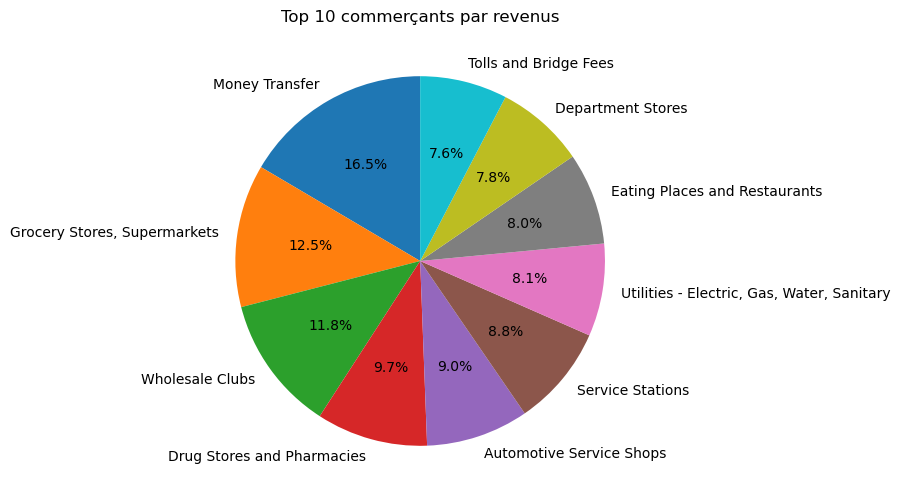

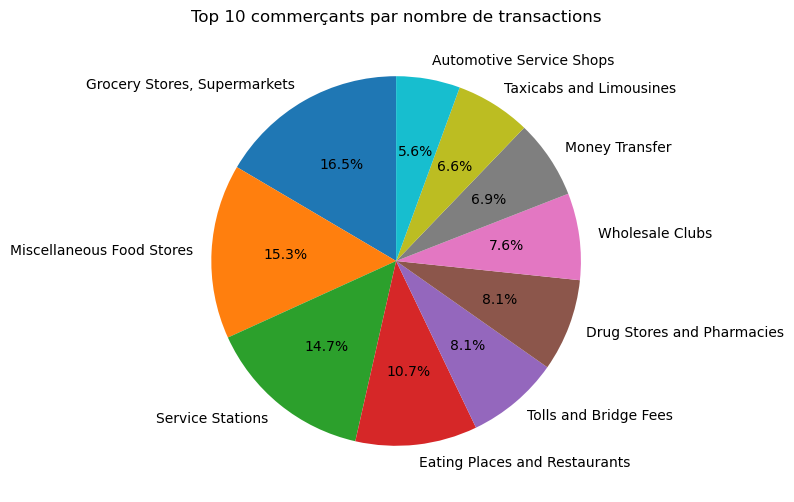

In [11]:
# Assure-toi que 'amount' est bien numérique
df['amount'] = pd.to_numeric(df['amount'], errors='coerce')

# Top 10 commerçants par revenus
top_revenue = df.groupby('description')['amount'].sum().sort_values(ascending=False).head(10)

# Top 10 commerçants par nombre de transactions
top_count = df['description'].value_counts().head(10)

# Diagramme en secteurs – revenus
plt.figure(figsize=(8, 6))
top_revenue.plot.pie(autopct='%1.1f%%', startangle=90)
plt.title('Top 10 commerçants par revenus')
plt.ylabel('')
plt.show()

# Diagramme en secteurs – nombre de transactions
plt.figure(figsize=(8, 6))
top_count.plot.pie(autopct='%1.1f%%', startangle=90)
plt.title('Top 10 commerçants par nombre de transactions')
plt.ylabel('')
plt.show()

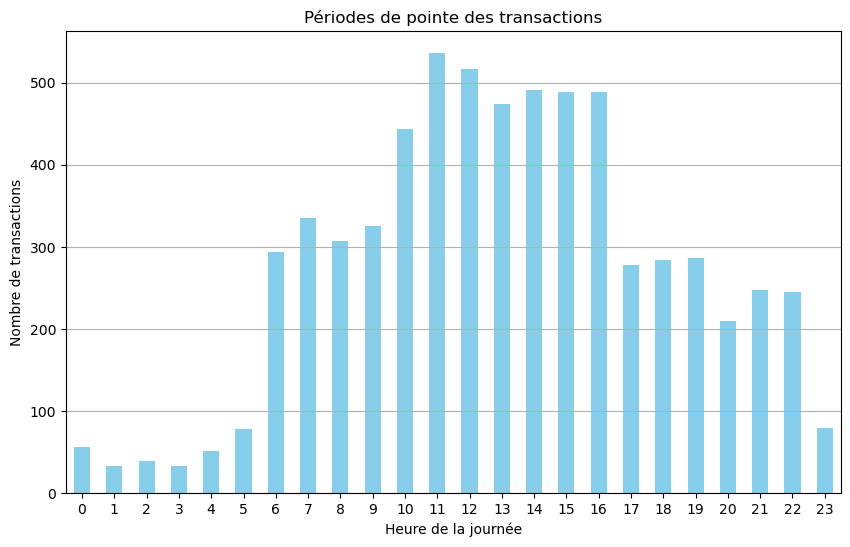

In [12]:
# Histogramme des heures
plt.figure(figsize=(10, 6))
df['heure'].value_counts().sort_index().plot(kind='bar', color='skyblue')
plt.title('Périodes de pointe des transactions')
plt.xlabel('Heure de la journée')
plt.ylabel('Nombre de transactions')
plt.xticks(rotation=0)
plt.grid(axis='y')
plt.show()


# **2. Analyse d'associations**

#### 2.1 *Transformation des données en données transactionnelles*


In [13]:
# Catégoriser l'heure
def categorize_hour(x):
    if x >= 22 or x < 6:
        return 'late_hour'
    else:
        return 'day_hour'
    
df['hour_category'] = df['heure'].apply(categorize_hour)

df['is_fraud_str'] = df['is_fraud'].apply(lambda x: 'Fraud' if x else 'NoFraud')

# Colonnes pour les transactions
cols_to_use =  ['card_type', 'credit_score_item', 'mcc_category', 'merchant_type', 'amount_category', 'is_fraud_str', 'hour_category']



# Gestion des valeurs manquantes
for col in cols_to_use:
    df[col] = df[col].astype(str).fillna('Unknown')

# Création des données transactionnelles (transactions)
def make_transactions(x):
    items = []
    for col in cols_to_use:
        items += x[col].tolist()
    items += x['is_fraud_str'].tolist()
    return items 

# Créer les transactions selon l'id de la carte
df_sample = df#.sample(5000) 
transactions = df_sample.groupby('card_id').apply(make_transactions).tolist()

C:\Users\lucna\AppData\Local\Temp\ipykernel_25412\1215160958.py:31: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  transactions = df_sample.groupby('card_id').apply(make_transactions).tolist()


In [14]:
te = TransactionEncoder()
te_array = te.fit(transactions).transform(transactions)

transactions_df = pd.DataFrame(te_array, columns=te.columns_)
transactions_df

,Airlines,"Amusement Parks, Carnivals, Circuses",Antique Shops,"Artist Supply Stores, Craft Shops","Athletic Fields, Commercial Sports",Automotive Body Repair Shops,Automotive Parts and Accessories Stores,Automotive Service Shops,Beauty and Barber Shops,"Betting (including Lottery Tickets, Casinos)",...,telecommunication_services,theatrical_producers,tolls_and_bridge_fees,"tools,_parts,_supplies_manufacturing",travel_agencies,"utilities_-_electric,_gas,_water,_sanitary",very_high,welding_repair,wholesale_clubs,women's_ready-to-wear_stores
0,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,True,False,False,False
1,False,False,False,True,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,True,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2510,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2511,False,False,False,False,False,False,False,False,False,False,...,True,False,False,False,False,False,True,False,False,False
2512,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2513,False,False,False,False,False,False,False,False,False,False,...,False,False,True,False,False,False,False,False,False,False


#### 2.2 *Génération de règles d'association par Apriori et FP-Growth*

In [15]:
# Génération des itemsets fréquents avec Apriori
frequent_itemsets_apriori = apriori(transactions_df, min_support=0.02, use_colnames=True)

# Génération des règles d'association
rules_apriori = association_rules(frequent_itemsets_apriori, metric="lift", min_threshold=1.2)

# Génération des itemsets fréquents avec FP-Growth
frequent_itemsets_fpgrowth = fpgrowth(transactions_df, min_support=0.02, use_colnames=True)

# Génération des règles d'association
rules_fpgrowth = association_rules(frequent_itemsets_fpgrowth, metric="lift", min_threshold=1.2)

# Conversion de frozenset à string pour une meilleure lisibilité
rules_apriori['antecedents'] = rules_apriori['antecedents'].apply(lambda x: ', '.join(list(x)) if x else '')
rules_apriori['consequents'] = rules_apriori['consequents'].apply(lambda x: ', '.join(list(x)) if x else '')

rules_fpgrowth['antecedents'] = rules_fpgrowth['antecedents'].apply(lambda x: ', '.join(list(x)) if x else '')
rules_fpgrowth['consequents'] = rules_fpgrowth['consequents'].apply(lambda x: ', '.join(list(x)) if x else '')

#### 2.3, 2.4 et 2.5 *Affichage des règles transactionnelles selon les questions*

In [16]:
# Question 2.3 : MCC et dépenses élevées
import re

mcc_types = df['mcc_category'].unique()
amount_type = df['amount_category'].unique()

mcc_regex = '|'.join([re.escape(x) for x in mcc_types])
amount_regex = 'high|very_high'

rules_mcc_expenses_ap = rules_apriori[
    (
        rules_apriori['antecedents'].str.contains(mcc_regex, case=False) &
        rules_apriori['consequents'].str.contains(amount_regex, case=False)
    )
    |
    (
        rules_apriori['antecedents'].str.contains(amount_regex, case=False) & 
        rules_apriori['consequents'].str.contains(mcc_regex, case=False)
    )
]

print("Règles d'association (MCC et dépenses élevées) - Apriori:")
for idx, row in rules_mcc_expenses_ap.head().iterrows():
    print(f"{row['antecedents']} -> {row['consequents']} (support: {row['support']:.3f}, lift: {row['lift']:.2f})")

rules_mcc_expenses_fp = rules_fpgrowth[
    (
        rules_fpgrowth['antecedents'].str.contains(mcc_regex, case=False) &
        rules_fpgrowth['consequents'].str.contains(amount_regex, case=False)
    )
    |
    (
        rules_fpgrowth['antecedents'].str.contains(amount_regex, case=False) & 
        rules_fpgrowth['consequents'].str.contains(mcc_regex, case=False)
    )
]

print("\nRègles d'association (MCC et dépenses élevées) - FP-Growth:")
for idx, row in rules_mcc_expenses_fp.head().iterrows():
    print(f"{row['antecedents']} -> {row['consequents']} (support: {row['support']:.3f}, lift: {row['lift']:.2f})")

Règles d'association (MCC et dépenses élevées) - Apriori:
Automotive Service Shops -> high (support: 0.060, lift: 1.63)
high -> Automotive Service Shops (support: 0.060, lift: 1.63)
Automotive Service Shops -> very_high (support: 0.045, lift: 1.23)
very_high -> Automotive Service Shops (support: 0.045, lift: 1.23)
high -> Department Stores (support: 0.051, lift: 1.31)

Règles d'association (MCC et dépenses élevées) - FP-Growth:
very_high -> Department Stores (support: 0.053, lift: 1.35)
Department Stores -> very_high (support: 0.053, lift: 1.35)
high -> Department Stores (support: 0.051, lift: 1.31)
Department Stores -> high (support: 0.051, lift: 1.31)
NoFraud, very_high -> Department Stores (support: 0.053, lift: 1.35)


Par la sortie qui suit, on voit que dans notre DataFrame prétraité, il y a des associations entre le type de commerce et les hautes dépenses. Les quatres commerces les plus concernés sont *Automotive Service Shops*, *Departement Stores*, *Miscellaneous Food Stores* et *Services Stations*, où les dépenses varient de hautes à très hautes. Les patterns comportementaux qui ressortent sont que les gens dépensent de grandes sommes dans les magasins départementales, dans les magasins de réparation automobile, dans les magasins de nourriture divers et dans les stations de services.

In [17]:
# Question 2.4 : Types de cartes et types de commerçants
import re

card_types = df['card_type'].unique()
merchant_types = df['merchant_type'].unique()

# Créer une regex qui matche n'importe quelle valeur
card_regex = '|'.join([re.escape(str(x)) for x in card_types])
merchant_regex = '|'.join([re.escape(str(x)) for x in merchant_types])

rules_card_merchant_ap = rules_apriori[
    (
        rules_apriori['antecedents'].str.contains(card_regex, case=False) & 
        rules_apriori['consequents'].str.contains(merchant_regex, case=False)
    )
    |
    (
        rules_apriori['antecedents'].str.contains(merchant_regex, case=False) & 
        rules_apriori['consequents'].str.contains(card_regex, case=False)
    )
]

print("Règles d'association (Types de cartes et types de commerçants) - Apriori:")
for idx, row in rules_card_merchant_ap.head().iterrows():
    print(f"{row['antecedents']} -> {row['consequents']} (support: {row['support']:.3f}, lift: {row['lift']:.2f})")

rules_card_merchant_fp = rules_fpgrowth[
    (
        rules_fpgrowth['antecedents'].str.contains(card_regex, case=False) &
        rules_fpgrowth['consequents'].str.contains(merchant_regex, case=False)
    )
    |
    (
        rules_fpgrowth['antecedents'].str.contains(merchant_regex, case=False) & 
        rules_fpgrowth['consequents'].str.contains(card_regex, case=False)
    )   
]

print("\nRègles d'association (Types de cartes et types de commerçants) - FP-Growth:")
for idx, row in rules_card_merchant_fp.head().iterrows():
    print(f"{row['antecedents']} -> {row['consequents']} (support: {row['support']:.3f}, lift: {row['lift']:.2f})")

Règles d'association (Types de cartes et types de commerçants) - Apriori:
money_transfer -> Credit (support: 0.039, lift: 1.26)
Credit -> money_transfer (support: 0.039, lift: 1.26)
utilities_-_electric,_gas,_water,_sanitary -> Credit (support: 0.021, lift: 1.34)
Credit -> utilities_-_electric,_gas,_water,_sanitary (support: 0.021, lift: 1.34)
tolls_and_bridge_fees -> credit_medium (support: 0.034, lift: 1.22)

Règles d'association (Types de cartes et types de commerçants) - FP-Growth:
credit_high, Department Stores -> department_stores (support: 0.055, lift: 10.98)
department_stores -> credit_high, Department Stores (support: 0.055, lift: 10.98)
NoFraud, credit_high, Department Stores -> department_stores (support: 0.055, lift: 10.98)
NoFraud, department_stores -> credit_high, Department Stores (support: 0.055, lift: 10.98)
credit_high, Department Stores -> NoFraud, department_stores (support: 0.055, lift: 10.98)


Ici, les deux seules associations pertinentes sont entre les commerçants transferant de l'argent et le type de carte *Credit* et entre les libraires et le type de carte *Debit*. Cela nous révèle que les utilisateurs utilisent surtout des cartes de crédit lorsqu'ils veulent transférer de l'argent et des cartes de débit pour acheter des livres.

In [18]:
# Question 2.5 : Fraude et autres variables
rules_fraud_ap = rules_apriori[
    ( 
        rules_apriori['consequents'].str.contains('Fraud', case=False)
    )
]

print("Règles d'association (Fraude et autres variables) - Apriori:")
for idx, row in rules_fraud_ap.head().iterrows():
    print(f"{row['antecedents']} -> {row['consequents']} (support: {row['support']:.3f}, lift: {row['lift']:.2f})")

rules_fraud_fp = rules_fpgrowth[
    ( 
        rules_fpgrowth['consequents'].str.contains('Fraud', case=False)
    )
]

print("\nRègles d'association (Fraude et autres variables) - FP-Growth:")
for idx, row in rules_fraud_fp.head().iterrows():
    print(f"{row['antecedents']} -> {row['consequents']} (support: {row['support']:.3f}, lift: {row['lift']:.2f})")

Règles d'association (Fraude et autres variables) - Apriori:
Automotive Service Shops -> NoFraud, automotive_service_shops (support: 0.085, lift: 11.81)
automotive_service_shops -> NoFraud, Automotive Service Shops (support: 0.085, lift: 11.81)
Automotive Service Shops -> NoFraud, high (support: 0.060, lift: 1.63)
high -> NoFraud, Automotive Service Shops (support: 0.060, lift: 1.63)
Automotive Service Shops -> NoFraud, very_high (support: 0.045, lift: 1.23)

Règles d'association (Fraude et autres variables) - FP-Growth:
credit_high, Debit, medium, very_high -> NoFraud, low (support: 0.032, lift: 1.21)
medium, credit_high, low -> NoFraud, Debit, very_high (support: 0.032, lift: 1.24)
credit_high, Debit, very_high -> medium, NoFraud, low (support: 0.032, lift: 1.20)
medium, low -> NoFraud, credit_high, Debit, very_high (support: 0.032, lift: 1.20)
Debit, very_high -> medium, credit_high, NoFraud, low (support: 0.032, lift: 1.24)


On peut voir qu'on ne trouve aucune corrélation entre les autres variables et la fraude, surtout parce que toutes les règles ne pointent pas vers de la fraude. On peut voir cela par le fait que le lift est supérieur au minimum posé, soit 1.2, signifiant une corrélation positive, surtout les deux premières règles crées par *Apriori*. 

#### 2.6 *Explication et visualisation des métriques associés aux règles*

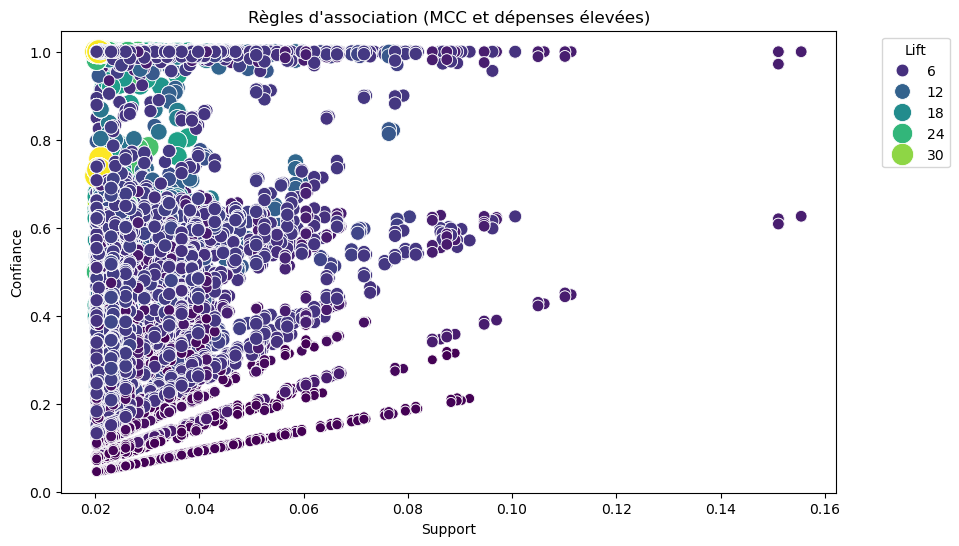

In [19]:
rules_mcc_expenses_copy = rules_mcc_expenses_ap.copy()

plt.figure(figsize=(10, 6))
sns.scatterplot(
    x='support',
    y='confidence',
    size='lift',
    hue='lift',
    data=rules_mcc_expenses_copy,
    palette='viridis',
    sizes=(50, 300)
)

plt.title('Règles d\'association (MCC et dépenses élevées)')
plt.xlabel('Support')
plt.ylabel('Confiance')
plt.legend(title='Lift', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

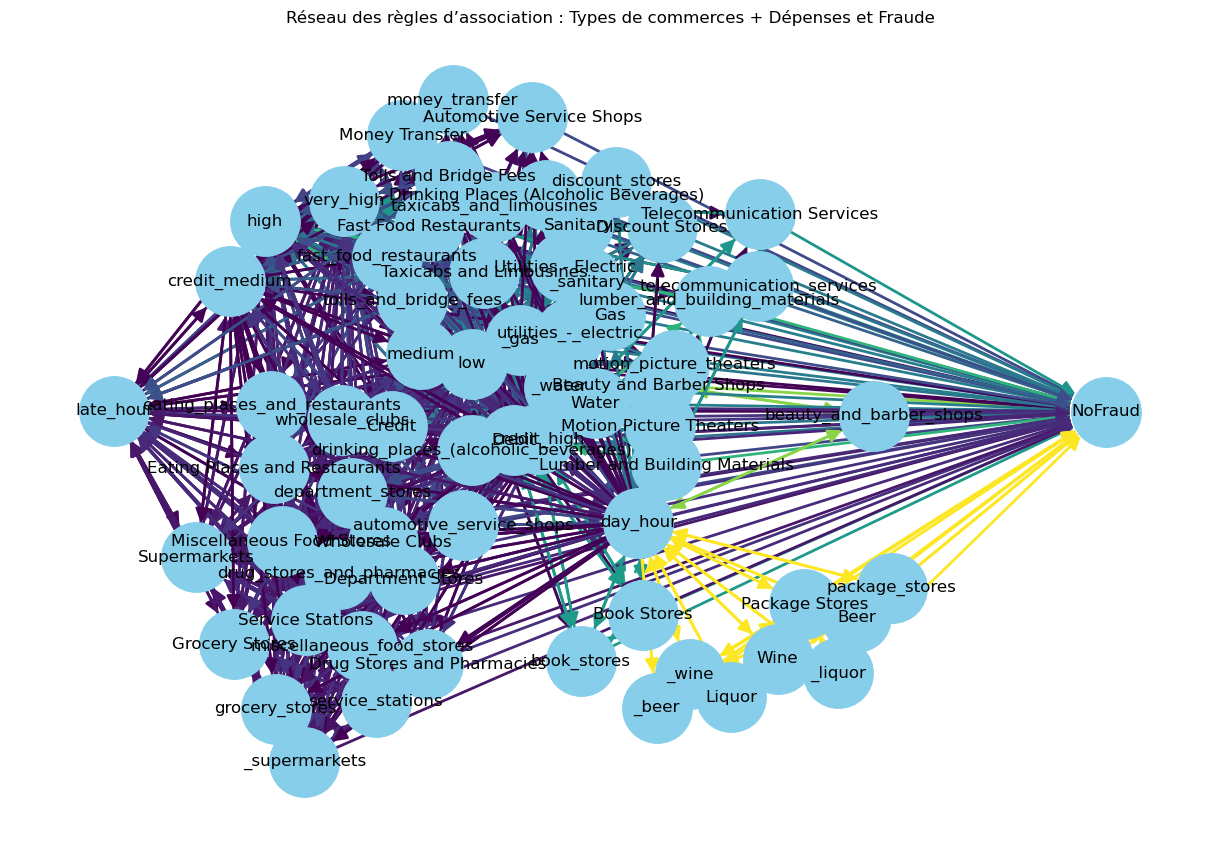

In [20]:
import networkx

rules_fraud_ap_copy = rules_fraud_ap.copy()

# Graphe orienté
G = networkx.DiGraph()

# Ajouter les arêtes avec les poids basés sur le lift
for idx, row in rules_fraud_ap_copy.iterrows():
    antecedents = [x.strip() for x in row['antecedents'].split(',')]
    consequents = [x.strip() for x in row['consequents'].split(',')]
    for a in antecedents:
        for c in consequents:
            G.add_edge(a, c, weight=row['lift'])

# Taille des arêtes basée sur le lift
edges = G.edges()
weights = [G[u][v]['weight']*2 for u,v in edges]

# Dessiner le graphe
plt.figure(figsize=(12, 8))
pos = networkx.spring_layout(G, k=0.5, seed=42)
networkx.draw(G, pos, with_labels=True, node_color='skyblue', node_size=2500, 
        edge_color=weights, width=2, edge_cmap=plt.cm.viridis, arrowsize=20)
plt.title('Réseau des règles d’association : Types de commerces + Dépenses et Fraude')
plt.show()


Le support correspond au pourcentage de *"popularité"* dans le sens que sur 2428 transactions, le pourcentage montré est le nombre de transactions où la règle apparaît le plus souvent. La confiance correspond au pourcentage de *"fiabilité*, soit que par rapport au support, un pourcentage de transactions suit une règle contenant plusieurs arguments à gauche comme un haut crédit, des dépenses basses et la librairie. Le lift correspond à la pertinence de la règle et si la limite posée est dépassée, cela signifie que ce n'est pas par hasard que les arguments de la règle sont associés entre eux (corrélation positive). Si on a un lift égal à la limite, les arguments de la règle sont indépendants (aucune corrélation). Si on a un lift inférieur à la limite, les arguments de la règle n'ont aucun lien entre eux (corrélation négative).

#### 2.7 *Choix du seuil du support minimal*

Pour le seuil de support minimal, on a choisi d'aller avec 0.02, afin de prendre en compte, à la fois les cas spécifiques et les cas généraux, sans avoir trop de bruit dans les données et sans manquer de cas spécifiques. Puisque qu'on est à un peu moins de 10 000 transactions, cette valeur est très justifié. 

(On a pris un échantillon de 10 000 pour des fins de tests. Lancer des millions de transactions dans des algorithmes comme *Apriori* et *FP-Growth* ne ferait que ralentir le processus en plus de causer énormément de bruit dans les résultats)

# **3. Analyse de séquence**

#### 3.1 *Construction des séquences clients*

Comment construire des séquences de transactions par clients ? 
À partir de quelle variable les ordonner ?

Pour construire des séquences client, une solution est d'ordonnancer les transactions par horodatage avec l'attribut `date` qui traduira une évolution dans le temps. Chaque séquence serait constituée d'itemsets formés d'attributs abstraits tels que `amount_category` qui permettent de comparer les comportements plus facilement. Dans ce cas d'étude, l'itemset modèle sera composé de:
- `merchant_type`
- `amount_category`
- `hour_category`
- `is_fraud_str`

Par la suite, on se rend compte qu'un itemset avec autant de conditions peut être trop restrictif (support minimale de 1% peu représentatif pour obtenir 3 séquences typiques seulement). Il peut alors être intéressant de se focaliser sur `merchant_type` et d'augmenter la taille de l'échantillon.

In [21]:
features = ['merchant_type', 'amount_category', 'hour_category', 'is_fraud_str']
df_seq = df[['card_id','date'] + features].sort_values(['card_id','date']).reset_index(drop='true')

# Pour chaque client, on veut l'ensemble des données ordonnées par horodatage 
sequences = (
    df_seq
    .groupby('card_id')[features[0]]
    .apply(list) # éléments en liste
    .tolist() # de DataFrame à liste
)

print("Nombre de clients et de leurs séquences de transactions: ", len(sequences))
pd.set_option("display.max_colwidth", 100)

Nombre de clients et de leurs séquences de transactions:  2515


Validation...

In [22]:
for i, seq in enumerate(sequences[:3]):
    print(f"Séquence {i+1} (longueur={len(seq)}):")
    for step in seq[:5]: 
        print("  ", step)
    if len(seq) > 5:
        print("  ...")
    print()

Séquence 1 (longueur=1):
   department_stores

Séquence 2 (longueur=1):
   artist_supply_stores,_craft_shops

Séquence 3 (longueur=2):
   miscellaneous_food_stores
   miscellaneous_food_stores



#### 3.2 *Parcours typiques avec l'algorithme PrefixSpan*

Identifier les parcours clients typiques par projection récursive de préfixes séquentiels.

In [24]:
from prefixspan import PrefixSpan

ps = PrefixSpan(sequences)
ps.minlen, ps.maxlen = 2, 5
# une séquence de 1 item ne fait pas sens,
# pour 10 000 transactions avec environ 2000 clients, 
# on a moins de 5 événements par client en moyenne


support_min = 0.02 # support significatif
motifs = ps.frequent(int(support_min*len(sequences)))

motif_df = (
    pd.DataFrame(motifs, columns=['support', 'motif'])
    .sort_values(['support'], ascending=[False])
    .reset_index(drop=True)
)

motif_df

,support,motif
0,186,"[miscellaneous_food_stores, miscellaneous_food_stores]"
1,151,"[service_stations, service_stations]"
2,91,"[grocery_stores,_supermarkets, grocery_stores,_supermarkets]"
3,91,"[tolls_and_bridge_fees, tolls_and_bridge_fees]"
4,80,"[miscellaneous_food_stores, miscellaneous_food_stores, miscellaneous_food_stores]"
5,71,"[taxicabs_and_limousines, taxicabs_and_limousines]"
6,70,"[service_stations, service_stations, service_stations]"
7,62,"[grocery_stores,_supermarkets, service_stations]"
8,60,"[grocery_stores,_supermarkets, eating_places_and_restaurants]"
9,57,"[eating_places_and_restaurants, eating_places_and_restaurants]"


#### 3.3 *Parcours d'achat et routine fréquentes*


#### 3.4 *Motifs précédant une transaction frauduleuse*

#### 3.5 *Évolutions du comportement*

#### 3.6 *Visualisations des comportements transactionnels*